In [42]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Computational Mechanics Project #01 - Heat Transfer in Forensic Science

We can use our current skillset for a macabre application. We can predict the time of death based upon the current temperature and change in temperature of a corpse. 

Forensic scientists use Newton's law of cooling to determine the time elapsed since the loss of life, 

$\frac{dT}{dt} = -K(T-T_a)$,

where $T$ is the current temperature, $T_a$ is the ambient temperature, $t$ is the elapsed time in hours, and $K$ is an empirical constant. 

Suppose the temperature of the corpse is 85$^o$F at 11:00 am. Then, 45
min later the temperature is 80$^{o}$F. 

Assume ambient temperature is a constant 65$^{o}$F.

**1.** Use Python to calculate $K$ using a finite difference approximation, $\frac{dT}{dt} \approx \frac{T(t+\Delta t)-T(t)}{\Delta t}$.

In [43]:
T0 = 85.0       # temperature at discovery, degrees F
T1 = 80.0       # temperature 45 minutes later, degrees F
Ta = 65.0       # ambient temperature, degrees F
dt_observed = 45 / 60  # hours

dTdt = (T1 - T0) / dt_observed
K = -dTdt / (T0 - Ta)
print(f"Estimated cooling rate: {dTdt:.6f} °F/hour")
print(f"K = {K:.6f} per hour")


Estimated cooling rate: -6.666667 °F/hour
K = 0.333333 per hour


In [44]:
Kb = -dTdt / (T1 - Ta)
print(f"K based on T1: {Kb:.6f} per hour")

K based on T1: 0.444444 per hour


**2.** Change your work from problem 1 to create a function that accepts the temperature at two times, ambient temperature, and the time elapsed to return $K$.

In [45]:
def return_K(T0, T1, Ta, dt):
    """
    Arguments:
    T0 (float): Initial temperature
    T1 (float): Final temperature
    Ta (float): Ambient temperature
    dt (float): Elapsed time

    Returns:
    float: Estimated cooling rate K
    """

    return -(T1 - T0) / (dt * (T0 - Ta))

In [46]:
K = return_K(T0, T1, Ta, dt_observed)
print(f"Function result: K =marker='o' {K:.6f} per hour")

Function result: K =marker='o' 0.333333 per hour


**3.** A first-order thermal system has the following analytical solution, 

$T(t) =T_a+(T(0)-T_a)e^{-Kt}$

where $T(0)$ is the temperature of the corpse at t=0 hours i.e. at the time of discovery and $T_a$ is a constant ambient temperature. 

a. Show that an Euler integration converges to the analytical solution as the time step is decreased. Use the constant $K$ derived above and the initial temperature, T(0) = 85$^o$F. 

b. What is the final temperature as t$\rightarrow\infty$?

c. At what time was the corpse 98.6$^{o}$F? i.e. what was the time of death?

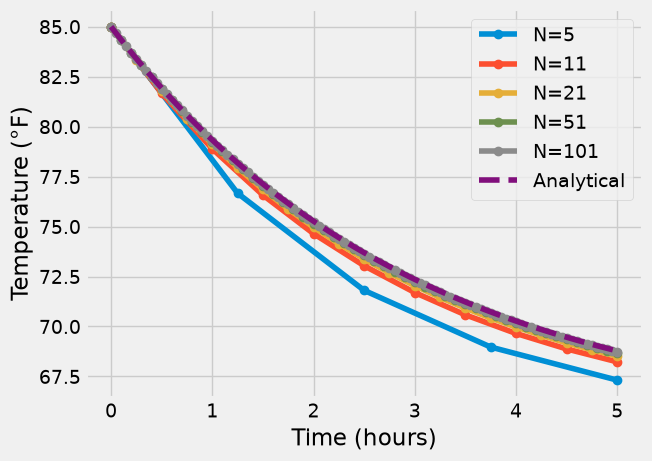

In [47]:
for N in [5, 11, 21, 51, 101]:
    t = np.linspace(0, 5, N)  # time in hours
    dt = t[1] - t[0]
    T = np.zeros_like(t)
    T[0] = T0
    for i in range(1, len(t)):
        DTdt = -K * (T[i-1] - Ta)
        T[i] = T[i-1] + DTdt * dt
    plt.plot(t, T, label=f'N={N}', marker='o')

T_an = lambda t: Ta + (T0 - Ta) * np.exp(-K * t)
plt.plot(t, T_an(t), '--', label='Analytical')
plt.xlabel('Time (hours)')
plt.ylabel('Temperature (°F)')
plt.legend()


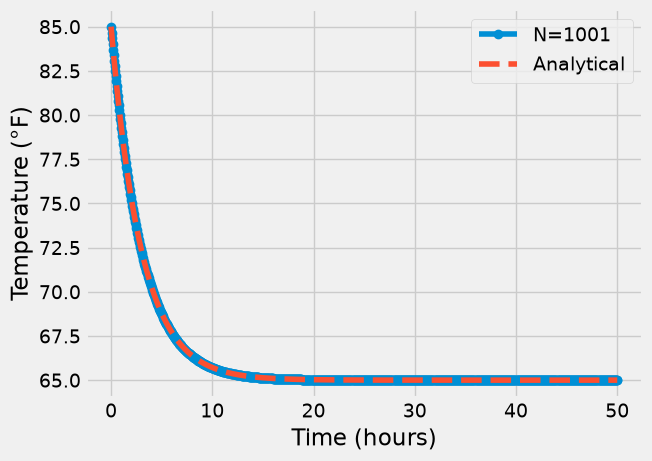

In [48]:
N = 1001
t = np.linspace(0, 50, N)  # time in hours
dt = t[1] - t[0]
T = np.zeros_like(t)
T[0] = T0
for i in range(1, len(t)):
    DTdt = -K * (T[i-1] - Ta)
    T[i] = T[i-1] + DTdt * dt
plt.plot(t, T, label=f'N={N}', marker='o')

T_an = lambda t: Ta + (T0 - Ta) * np.exp(-K * t)
plt.plot(t, T_an(t), '--', label='Analytical')
plt.xlabel('Time (hours)')
plt.ylabel('Temperature (°F)')
plt.legend()


In [49]:
T[-1]

np.float64(65.00000100413303)

In [50]:
T_an(1000)

np.float64(65.0)

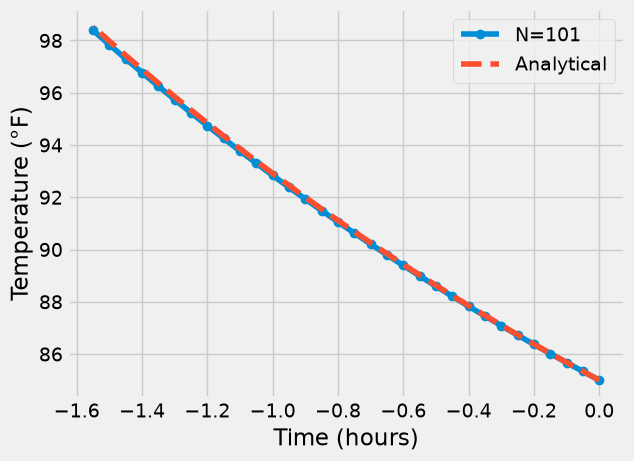

In [51]:
T[0] = T0
Ta = 65
N = 101
t = np.linspace(0, 5, N)  # time in hours
dt = t[1] - t[0]
T = np.zeros_like(t)
T[0] = T0
for i in range(1, len(t)):
    DTdt = -K * (T[i-1] - Ta)
    T[i] = T[i-1] - DTdt * dt

iT = T<98.6

plt.plot(-t[iT], T[iT], label=f'N={N}', marker='o')

T_an = lambda t: Ta + (T0 - Ta) * np.exp(-K * t)
plt.plot(-t[iT], T_an(-t[iT]), '--', label='Analytical')
plt.xlabel('Time (hours)')
plt.ylabel('Temperature (°F)')
plt.legend()


In [53]:
print(f"Time of death: {-t[iT][-1]:.2f} hours")

Time of death: -1.55 hours
